In [1]:
import os 
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/shogohuangg/urmp-evaluation/AuSep_1_vn_02_Sonata.wav
/kaggle/input/datasets/shogohuangg/urmp-evaluation/F0s_1_vn_17_Nocturne.txt
/kaggle/input/datasets/shogohuangg/urmp-evaluation/F0s_1_vn_24_Pirates.txt
/kaggle/input/datasets/shogohuangg/urmp-evaluation/F0s_2_vn_19_Pavane.txt
/kaggle/input/datasets/shogohuangg/urmp-evaluation/F0s_1_vn_12_Spring.txt
/kaggle/input/datasets/shogohuangg/urmp-evaluation/AuSep_1_vn_12_Spring.wav
/kaggle/input/datasets/shogohuangg/urmp-evaluation/AuSep_2_vn_19_Pavane.wav
/kaggle/input/datasets/shogohuangg/urmp-evaluation/AuSep_1_vn_17_Nocturne.wav
/kaggle/input/datasets/shogohuangg/urmp-evaluation/F0s_1_vn_02_Sonata.txt
/kaggle/input/datasets/shogohuangg/urmp-evaluation/AuSep_1_vn_24_Pirates.wav
/kaggle/input/datasets/shogohuangg/training-scaffold/2313.csv
/kaggle/input/datasets/shogohuangg/training-scaffold/2431.csv
/kaggle/input/datasets/shogohuangg/training-scaffold/2659.csv
/kaggle/input/datasets/shogohuangg/training-scaffold/2244.

2.10.0+cu128
True
20 training files,  5 testing files
Spectrogram shape: torch.Size([1, 1025, 38280])
Piano roll shape: torch.Size([38280, 88])


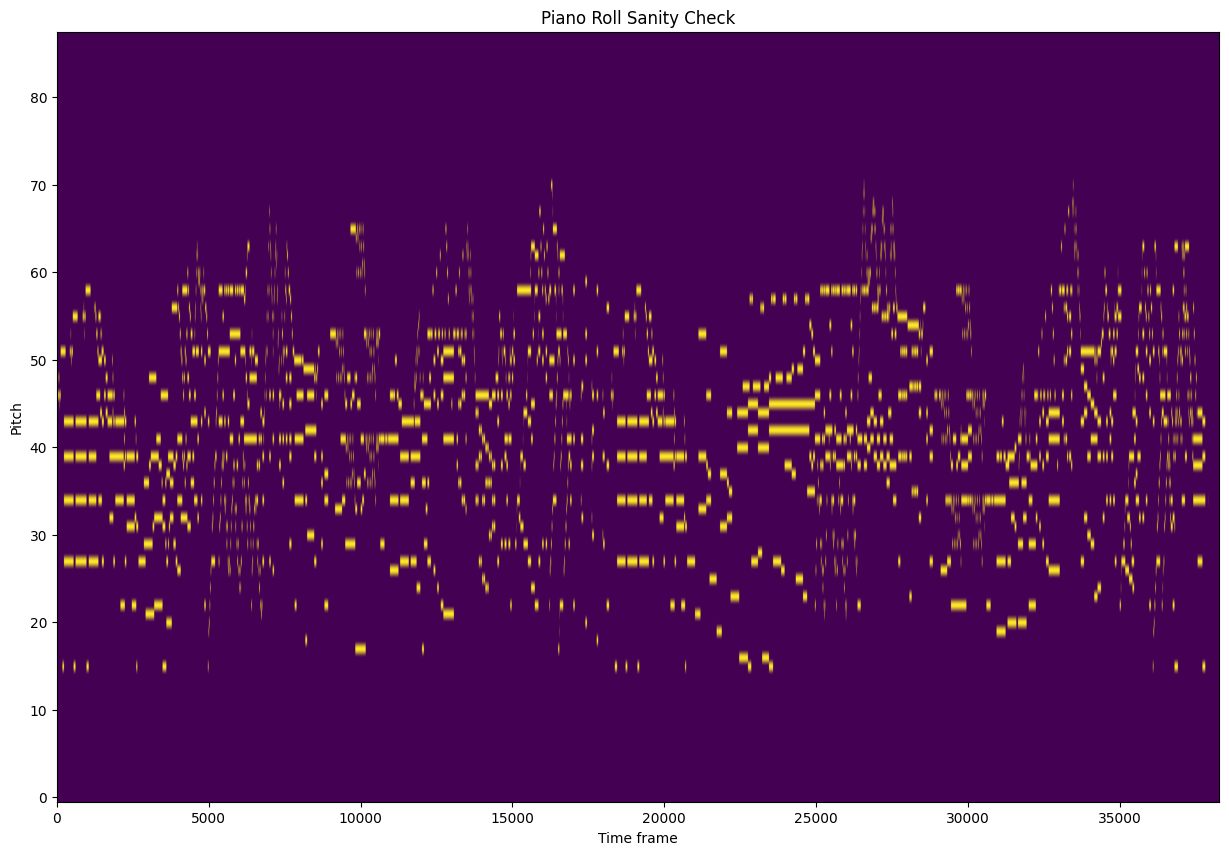

CRNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=(4, 1), stride=(4, 1), padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=(4, 1), stride=(4, 1), padding=0, dilation=1, ceil_mode=False)
  (lstm): LSTM(1024, 128, num_layers=2, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=256, out_features=88, bias=True)
)
torch.Size([1, 300, 88])
Loading training
  train piece 1/20: 128 chunks (38280 frames)
  train piece 2/20: 84 chunks (25133 frames)
  train piece 3/20: 141 chunks (42278 frames)
  train piece 4/20: 102 chunks (30598 frames)
  train piece 5/20: 146 chunks (43502 frames)
  train pie

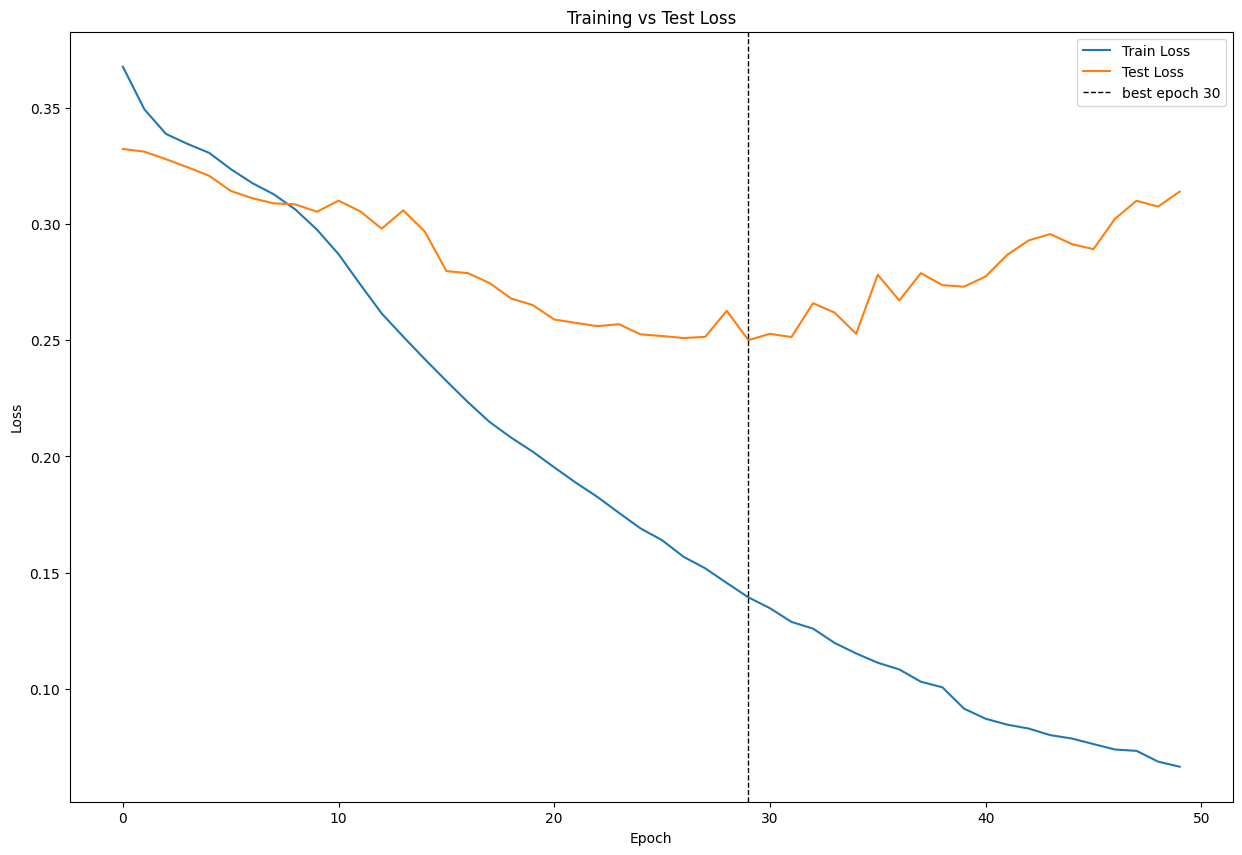

probs min/max/mean: 4.363449532251984e-11 0.9984785914421082 0.07962267845869064


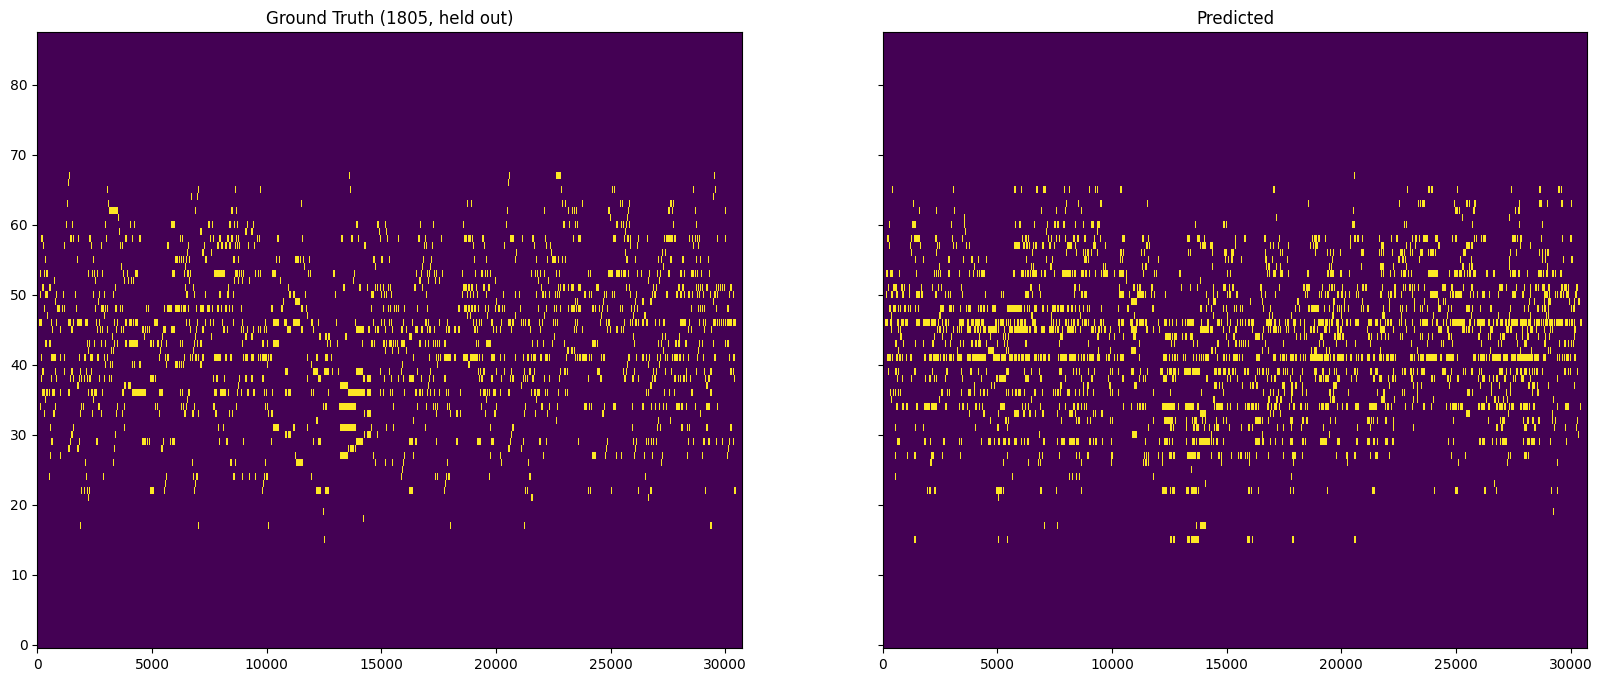

defined: <function urmp_f0_to_notes at 0x7dc5dd324fe0> <function audio_to_spec at 0x7dc5e41f7420>
CRNN 1805: P=0.105 R=0.154 F1=0.125  (ref 3619 / est 5301 notes)
CRNN 1788: P=0.126 R=0.173 F1=0.146  (ref 5016 / est 6887 notes)
CRNN 1789: P=0.068 R=0.138 F1=0.091  (ref 2391 / est 4864 notes)
CRNN 1790: P=0.137 R=0.175 F1=0.154  (ref 3195 / est 4088 notes)
CRNN 1793: P=0.043 R=0.109 F1=0.061  (ref 2391 / est 6103 notes)

CRNN mean F1: 0.1154
Predicting MIDI for /kaggle/input/datasets/shogohuangg/training-scaffold/1805.wav...
basic-pitch OK. first note event: (np.float64(352.88031156462586), np.float64(353.61302403628116), np.int64(32), np.float32(0.50669473), [np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int6

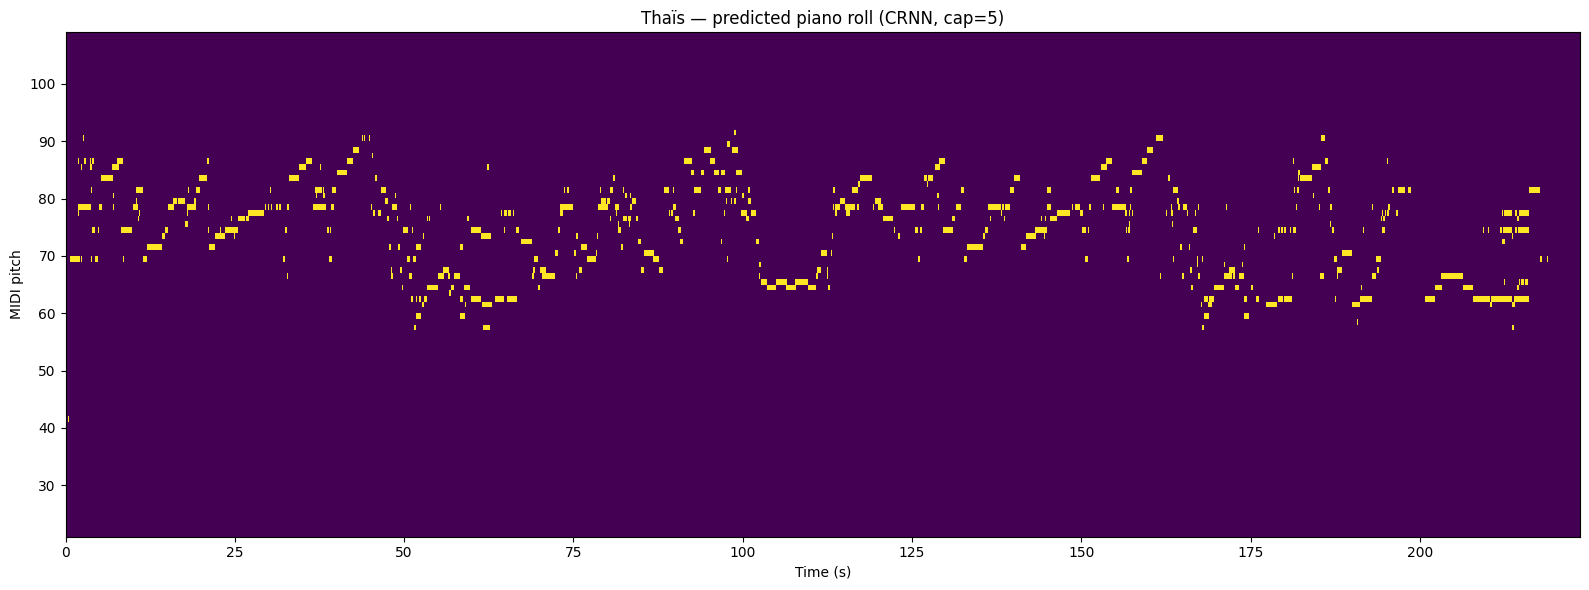

wrote thais_prediction.mid: 776 notes, 218.8 s


In [5]:
!pip install mir_eval

!pip install basic_pitch --no-deps
!pip install onnxruntime pretty-midi resampy
import torch
import librosa
import soundfile
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

print(torch.__version__)
print(torch.cuda.is_available())

data_dir = "/kaggle/input/datasets/shogohuangg/training-scaffold"

training_files = [1807, 2105, 2177, 2178, 2179, 2180, 2186, 2191, 2241, 2242, 2243, 2244, 2288, 2289, 2313, 2314, 2315, 2431, 2432, 2659]
test_files = [1805, 1788, 1789, 1790, 1793]

assert not set(training_files)& set(test_files), "overlap between train and test"
print(len(training_files), "training files, ", len(test_files), "testing files")

missing = []
for p in training_files + test_files:
    if not os.path.exists(f"{data_dir}/{p}.wav"): missing.append(f"{p}.wav")
    if not os.path.exists(f"{data_dir}/{p}.csv"): missing.append(f"{p}.csv")
assert not missing, f"missing: {missing}"
 
train_audio = [f"{data_dir}/{p}.wav" for p in training_files]
train_notes = [f"{data_dir}/{p}.csv" for p in training_files]
test_audio  = [f"{data_dir}/{p}.wav" for p in test_files]
test_notes  = [f"{data_dir}/{p}.csv" for p in test_files]


class MusicDataset(Dataset):
    def __init__(self, audio_files, label_files):
        self.audio_files = audio_files
        self.label_files = label_files

    def __len__(self):
        return len(self.audio_files)

    def __getitem__(self, index):
        audio_path = self.audio_files[index]
        label_path = self.label_files[index]
        y, sr = librosa.load(audio_path, sr=None)
        D = librosa.stft(y)
        S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
        S_db = (S_db - S_db.mean()) / (S_db.std() + 1e-6)
        spectrogram_tensor = torch.tensor(S_db, dtype=torch.float32)
        spectrogram_tensor = spectrogram_tensor.unsqueeze(0)

        labels_df = pd.read_csv(label_path)
        hop_length = 512
        n_frame = spectrogram_tensor.shape[-1]
        piano_roll = torch.zeros(n_frame, 88)

        for _, row in labels_df.iterrows():
            start_frame = int(row['start_time']) // hop_length
            end_frame = int(row['end_time']) // hop_length
            pitch_idx = int(row['note']) - 21
            if 0 <= pitch_idx < 88:
                piano_roll[start_frame:end_frame, pitch_idx] = 1

        return spectrogram_tensor, piano_roll


train_dataset = MusicDataset(train_audio, train_notes)
test_dataset = MusicDataset(test_audio, test_notes)
dataset = train_dataset
    
spectrogram, piano_roll = dataset[0]
print("Spectrogram shape:", spectrogram.shape)
print("Piano roll shape:", piano_roll.shape)

plt.figure(figsize=(15,10))
plt.imshow(piano_roll.T, aspect='auto', origin='lower')
plt.xlabel("Time frame")
plt.ylabel("Pitch")
plt.title("Piano Roll Sanity Check")
plt.show()


class CRNN(nn.Module):
    def __init__(self, num_freq_bins=1025, cnn_channels=16, hidden_size=128, num_classes=88):
        super(CRNN, self).__init__()
        self.conv1 = nn.Conv2d(1, cnn_channels, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d((2,1))   

        self.conv2 = nn.Conv2d(cnn_channels, cnn_channels*2, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d((4,1))  

        self.conv3 = nn.Conv2d(cnn_channels*2, cnn_channels*2, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d((4,1))

        lstm_input = cnn_channels*2*32  

        self.lstm = nn.LSTM(input_size=lstm_input, hidden_size=hidden_size, num_layers=2,
                             batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size*2, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        batch_size, channels, freq, time = x.shape
        x = x.permute(0,3,1,2).reshape(batch_size, time, channels*freq)
        x, _ = self.lstm(x)
        x = self.fc(x)
        return x

CHUNK_LEN = 300

def chunkify(spec, roll=None, chunk_len=CHUNK_LEN):
    T = spec.shape[-1]
    pad = (-T) % chunk_len
    if pad:
        spec = torch.nn.functional.pad(spec, (0, pad))
        if roll is not None:
            roll = torch.nn.functional.pad(roll, (0, 0, 0, pad))
    n = spec.shape[-1] // chunk_len
    X = spec.reshape(1, spec.shape[1], n, chunk_len).permute(2, 0, 1, 3).contiguous()
    Y = roll.reshape(n, chunk_len, 88).contiguous() if roll is not None else None
    return X, Y, T

@torch.no_grad()
def predict_full(model, spec, batch=8):
    X, _, T = chunkify(spec)
    was_training = model.training
    model.eval()
    out = [torch.sigmoid(model(X[i:i+batch].cuda())).cpu() for i in range(0, len(X), batch)]
    if was_training:
        model.train()
    return torch.cat(out).reshape(-1, 88)[:T]
    
model = CRNN().cuda()
print(model)
output = model(spectrogram.unsqueeze(0)[:, :, :, :CHUNK_LEN].cuda())
print(output.shape)

def build_chunks(ds, name):
    Xs, Ys = [], []
    for i in range(len(ds)):
        spec, roll = ds[i]
        Xi, Yi, Ti, = chunkify(spec, roll)
        Xs.append(Xi)
        Ys.append(Yi)
        print(f"  {name} piece {i+1}/{len(ds)}: {Xi.shape[0]} chunks ({Ti} frames)")
    X=torch.cat(Xs)
    Y=torch.cat(Ys)
    print(f"{name}: {X.shape[0]} chunks total")
    total = Y.numel()
    positives = Y.sum().item()
    pos_ratio = positives / total
    print(f"Total positions: {total}")
    print(f"Positive positions: {int(positives)} ({pos_ratio*100:.3f}%)")
    print(f"Natural pos_weight = {(1-pos_ratio)/pos_ratio:.1f}")
    active_per_frame = Y.sum(dim=-1)
    print(f"Mean active pitches per frame: {active_per_frame.mean():.2f}")
    print(f"Frames with 0 active pitches: {(active_per_frame==0).sum().item()} ({(active_per_frame==0).float().mean()*100:.1f}%)")
    
    return X, Y

print("Loading training")
X, Y = build_chunks(train_dataset, "train")
print("Loaidng testing")
Xt, Yt = build_chunks(test_dataset, "test")

n_chunks=X.shape[0]
n_test_chunks=Xt.shape[0]

epochs = 100
train_loss_history = []
test_loss_history = []


num_pos = Y.sum()
num_neg = Y.numel()-num_pos
pos_weight = (num_neg/num_pos).clone().detach().cuda()
pos_weight = torch.clamp(pos_weight, max=5.0)
print("pos_weight:", pos_weight.item())

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=8)

best_test_loss = float('inf')
best_train_at_best=None
best_epoch=-1
best_state=None
epochs_since_improve=0
patience=20

for epoch in range(epochs):
    model.train()
    perm = torch.randperm(n_chunks)
    running = 0.0
    for i in range(0, n_chunks, 8):
        idx = perm[i:i+8]
        xb, yb = X[idx].cuda(), Y[idx].cuda()
        optimizer.zero_grad()
        output = model(xb)
        loss = criterion(output, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running += loss.item() * xb.size(0)

    epoch_loss = running / n_chunks
    train_loss_history.append(epoch_loss)
    model.eval()
    test_running = 0.0
    with torch.no_grad():
        for i in range(0, n_test_chunks, 8):
            xb, yb = Xt[i:i+8].cuda(), Yt[i:i+8].cuda()
            test_running += criterion(model(xb), yb).item() * xb.size(0)

    epoch_test_loss=test_running/n_test_chunks
    test_loss_history.append(epoch_test_loss)
    scheduler.step(epoch_test_loss)

    if epoch_test_loss < best_test_loss:
        best_test_loss = epoch_test_loss
        best_train_at_best = epoch_loss
        best_epoch = epoch
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_since_improve = 0
    else:
        epochs_since_improve += 1

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {epoch_loss:.4f}, Test Loss: {test_loss_history[-1]:.4f}")
    if epochs_since_improve >= patience:
        print(f"Early stop at epoch {epoch+1}. Best epoch: {best_epoch+1}.")
        break
        
model.load_state_dict(best_state)
print(f" best epoch:       {best_epoch+1}")
print(f" test loss @ best: {best_test_loss:.4f}")
print(f" train @ best:     {best_train_at_best:.4f}  |  gap: {best_test_loss - best_train_at_best:+.4f}")


print("Per-piece held-out loss:")
for i in range(len(test_dataset)):
    spec_i, roll_i = test_dataset[i]
    Xi, Yi, _ = chunkify(spec_i, roll_i)
    with torch.no_grad():
        run = 0.0
        for j in range(0, Xi.shape[0], 8):
            xb, yb = Xi[j:j+8].cuda(), Yi[j:j+8].cuda()
            run += criterion(model(xb), yb).item() * xb.size(0)
    print(f"  {test_files[i]}: {run/Xi.shape[0]:.4f}")

plt.figure(figsize=(15,10))
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Test Loss")
plt.plot(train_loss_history, label="Train Loss")
plt.plot(test_loss_history, label="Test Loss")
plt.axvline(best_epoch, ls="--", c="k", lw=1, label=f"best epoch {best_epoch+1}")
plt.legend()
plt.show()


test_spectrogram, test_piano_roll = test_dataset[0]
probs = predict_full(model, test_spectrogram)
preds = (probs > 0.5).float()

print("probs min/max/mean:", probs.min().item(), probs.max().item(), probs.mean().item())

fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)
axes[0].imshow(test_piano_roll[:preds.shape[0]].T, aspect='auto', origin='lower', interpolation='nearest')
axes[0].set_title(f"Ground Truth ({test_files[0]}, held out)")
axes[1].imshow(preds.T, aspect='auto', origin='lower', interpolation='nearest')
axes[1].set_title("Predicted")
plt.show()
import os, glob, re
import numpy as np, torch, librosa
from scipy.ndimage import median_filter

def urmp_f0_to_notes(txt_path, min_note_sec=0.05):
    data = np.loadtxt(txt_path)
    times, freqs = data[:, 0], data[:, 1]
    midi = np.full(len(freqs), -1, dtype=int)
    voiced = freqs > 0
    midi[voiced] = np.round(librosa.hz_to_midi(freqs[voiced])).astype(int)
    dt = np.median(np.diff(times)) if len(times) > 1 else 0.01
    intervals, pitches_hz = [], []
    i, n = 0, len(times)
    while i < n:
        if midi[i] < 0:
            i += 1; continue
        j = i
        while j + 1 < n and midi[j + 1] == midi[i]:
            j += 1
        start, end = times[i], times[j] + dt
        if end - start >= min_note_sec:
            intervals.append((start, end))
            pitches_hz.append(librosa.midi_to_hz(midi[i]))
        i = j + 1
    return np.array(intervals, dtype=float).reshape(-1, 2), np.array(pitches_hz, dtype=float)

def audio_to_spec(audio_path, target_sr=44100):
    y, _ = librosa.load(audio_path, sr=target_sr)
    D = librosa.stft(y)
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    S_db = (S_db - S_db.mean()) / (S_db.std() + 1e-6)
    return torch.tensor(S_db, dtype=torch.float32).unsqueeze(0)

print("defined:", urmp_f0_to_notes, audio_to_spec)
from mir_eval.transcription import precision_recall_f1_overlap

def piano_roll_to_notes(piano_roll, hop_length=512, sr=44100, threshold=0.5):
    if torch.is_tensor(piano_roll):
        binary = (piano_roll > threshold).cpu().numpy().astype(np.int8)
    else:
        binary = (piano_roll > threshold).astype(np.int8)
    intervals, pitches_hz = [], []
    for pitch_idx in range(piano_roll.shape[1]):
        col = binary[:, pitch_idx]
        diffs = np.diff(np.concatenate([[0], col, [0]]))
        onsets  = np.where(diffs == 1)[0]
        offsets = np.where(diffs == -1)[0]
        for on, off in zip(onsets, offsets):
            intervals.append((on * hop_length / sr, off * hop_length / sr))
            pitches_hz.append(librosa.midi_to_hz(pitch_idx + 21))
    intervals  = np.array(intervals, dtype=float).reshape(-1, 2)   
    pitches_hz = np.array(pitches_hz, dtype=float)
    return intervals, pitches_hz

def score(ref_i, ref_p, est_i, est_p):
    p, r, f1, _ = precision_recall_f1_overlap(
        ref_i, ref_p, est_i, est_p,
        onset_tolerance=0.05, pitch_tolerance=50.0, offset_ratio=None)
    return p, r, f1
def csv_to_notes(csv_path, sr=44100, lo=21, hi=108):
    df = pd.read_csv(csv_path)
    m = (df['note'] >= lo) & (df['note'] <= hi)
    df = df[m]
    intervals = np.stack([df['start_time'].values / sr,
                          df['end_time'].values / sr], axis=1).astype(float)
    pitches_hz = librosa.midi_to_hz(df['note'].values.astype(int))
    return intervals.reshape(-1, 2), pitches_hz

def probs_to_notes(probs, hop_length=512, sr=44100, threshold=0.5,
                   med_frames=5, min_note_frames=3):
    if torch.is_tensor(probs):
        probs = probs.cpu().numpy()
    if med_frames > 1:
        probs = median_filter(probs, size=(med_frames, 1))
    binary = (probs > threshold).astype(np.int8)
    intervals, pitches_hz = [], []
    for pitch_idx in range(binary.shape[1]):
        col = binary[:, pitch_idx]
        diffs = np.diff(np.concatenate([[0], col, [0]]))
        for on, off in zip(np.where(diffs == 1)[0], np.where(diffs == -1)[0]):
            if off - on < min_note_frames:
                continue
            intervals.append((on * hop_length / sr, off * hop_length / sr))
            pitches_hz.append(librosa.midi_to_hz(pitch_idx + 21))
    return (np.array(intervals, dtype=float).reshape(-1, 2),
            np.array(pitches_hz, dtype=float))
SR = 44100
for pid in test_files:
    assert librosa.get_samplerate(f"{data_dir}/{pid}.wav") == SR, f"{pid} not {SR} Hz"

best_th = 0.5   # replace with the value your tuning cell printed, if you ran it

refs, crnn_rows = {}, []
for i, pid in enumerate(test_files):
    ref_i, ref_p = csv_to_notes(test_notes[i], sr=SR)   # clean reference from CSV
    refs[pid] = (ref_i, ref_p)

    spec_i, _ = test_dataset[i]
    probs_i = predict_full(model, spec_i)
    est_i, est_p = probs_to_notes(probs_i, sr=SR, threshold=best_th)
    p, r, f1 = score(ref_i, ref_p, est_i, est_p)
    crnn_rows.append({"piece": pid, "precision": p, "recall": r, "f1": f1})
    print(f"CRNN {pid}: P={p:.3f} R={r:.3f} F1={f1:.3f}  (ref {len(ref_i)} / est {len(est_i)} notes)")

crnn_f1_mean = float(np.mean([row["f1"] for row in crnn_rows]))
print(f"\nCRNN mean F1: {crnn_f1_mean:.4f}")

from basic_pitch.inference import predict as bp_predict
from basic_pitch import ICASSP_2022_MODEL_PATH

_, _, ne = bp_predict(f"{data_dir}/{test_files[0]}.wav", ICASSP_2022_MODEL_PATH)
print("basic-pitch OK. first note event:", ne[0])  

bp_rows = []
for pid in test_files:
    _, _, note_events = bp_predict(f"{data_dir}/{pid}.wav", ICASSP_2022_MODEL_PATH)
    if len(note_events):
        est_i = np.array([[e[0], e[1]] for e in note_events], dtype=float)
        est_p = np.array([librosa.midi_to_hz(e[2]) for e in note_events], dtype=float)
    else:
        est_i, est_p = np.zeros((0, 2)), np.zeros((0,))
    ref_i, ref_p = refs[pid]
    p, r, f1 = score(ref_i, ref_p, est_i, est_p)
    bp_rows.append({"piece": pid, "precision": p, "recall": r, "f1": f1})
    print(f"BasicPitch {pid}: P={p:.3f} R={r:.3f} F1={f1:.3f}")

bp_f1_mean = float(np.mean([row["f1"] for row in bp_rows]))
print(f"\nBasic Pitch mean F1: {bp_f1_mean:.4f}")

comp = pd.DataFrame({
    "piece":         test_files,
    "CRNN_P":        [r["precision"] for r in crnn_rows],
    "CRNN_R":        [r["recall"]    for r in crnn_rows],
    "CRNN_F1":       [r["f1"]        for r in crnn_rows],
    "BasicPitch_F1": [r["f1"]        for r in bp_rows],
    "delta_pp":      [(c["f1"] - b["f1"]) * 100 for c, b in zip(crnn_rows, bp_rows)],
})
mean_row = {"piece": "mean", "CRNN_P": comp["CRNN_P"].mean(), "CRNN_R": comp["CRNN_R"].mean(),
            "CRNN_F1": crnn_f1_mean, "BasicPitch_F1": bp_f1_mean, "delta_pp": comp["delta_pp"].mean()}
comp = pd.concat([comp, pd.DataFrame([mean_row])], ignore_index=True)
print(comp.round(3).to_string(index=False))
comp.to_csv("f1_comparison.csv", index=False)
print("\nSaved f1_comparison.csv")


import os, glob, re

urmp_root = "/kaggle/input/datasets/shogohuangg/urmp-evaluation"   

def find_urmp_violin(root, limit=5):
    wavs = glob.glob(f"{root}/**/AuSep_*_vn_*.wav", recursive=True)
    txts = glob.glob(f"{root}/**/F0s_*_vn_*.txt", recursive=True)

    def key(path):                     
        m = re.search(r"vn_(.+?)\.(wav|txt)$", os.path.basename(path))
        return m.group(1) if m else None

    f0_by_key = {key(t): t for t in txts if not os.path.basename(t).startswith("._")}
    pairs = []
    for w in sorted(wavs):
        if os.path.basename(w).startswith("._"):
            continue
        f0 = f0_by_key.get(key(w))
        if f0:
            pairs.append((os.path.basename(w)[:-4], w, f0))
    return pairs[:limit]

urmp_pieces = find_urmp_violin(urmp_root, limit=5)
for name, w, f0 in urmp_pieces:
    print(name, "<->", os.path.basename(f0))
assert urmp_pieces, "still empty — paste the os.walk output"

URMP_SR = 44100
urmp_crnn_rows, urmp_bp_rows = [], []

for name, wav, f0 in urmp_pieces:
    ref_i, ref_p = urmp_f0_to_notes(f0)                 
    spec = audio_to_spec(wav, URMP_SR)
    probs = predict_full(model, spec)
    est_i, est_p = probs_to_notes(probs, sr=URMP_SR, threshold=best_th)
    p, r, f1 = score(ref_i, ref_p, est_i, est_p)
    urmp_crnn_rows.append({"piece": name, "precision": p, "recall": r, "f1": f1})
    print(f"CRNN       {name}: P={p:.3f} R={r:.3f} F1={f1:.3f}  (ref {len(ref_i)} / est {len(est_i)})")

    _, _, ne = bp_predict(wav, ICASSP_2022_MODEL_PATH)
    if len(ne):
        bp_i = np.array([[e[0], e[1]] for e in ne], dtype=float)
        bp_p = np.array([librosa.midi_to_hz(e[2]) for e in ne], dtype=float)
    else:
        bp_i, bp_p = np.zeros((0, 2)), np.zeros((0,))
    p, r, f1 = score(ref_i, ref_p, bp_i, bp_p)
    urmp_bp_rows.append({"piece": name, "precision": p, "recall": r, "f1": f1})
    print(f"BasicPitch {name}: P={p:.3f} R={r:.3f} F1={f1:.3f}")

urmp = pd.DataFrame({
    "piece":         [r["piece"] for r in urmp_crnn_rows],
    "CRNN_F1":       [r["f1"]    for r in urmp_crnn_rows],
    "BasicPitch_F1": [r["f1"]    for r in urmp_bp_rows],
})
urmp["delta_pp"] = (urmp["CRNN_F1"] - urmp["BasicPitch_F1"]) * 100
urmp.loc["mean"] = ["mean", urmp["CRNN_F1"].mean(), urmp["BasicPitch_F1"].mean(), urmp["delta_pp"].mean()]
print(urmp.round(3).to_string(index=False))
urmp.to_csv("urmp_f1_comparison.csv", index=False)

import pretty_midi

thais_audio_path = "/kaggle/input/datasets/shogohuangg/thais/Thais.wav"   
THRESHOLD = 0.5

spec  = audio_to_spec(thais_audio_path, target_sr=44100)   
probs = predict_full(model, spec)                          
roll  = (probs > THRESHOLD).float()

print("frames:", roll.shape[0],
      "| duration ~ %.1f s" % (roll.shape[0] * 512 / 44100),
      "| active cells:", int(roll.sum().item()))

plt.figure(figsize=(16, 6))
plt.imshow(roll.T.cpu().numpy(), aspect='auto', origin='lower',
           interpolation='nearest',
           extent=[0, roll.shape[0]*512/44100, 21, 109])
plt.xlabel("Time (s)"); plt.ylabel("MIDI pitch")
plt.title("Thaïs — predicted piano roll (CRNN, cap=5)")
plt.tight_layout(); plt.show()

def piano_roll_to_pretty_midi(piano_roll, hop_length=512, sr=44100,
                              threshold=0.5, program=40, velocity=100,
                              min_note_frames=2):
    """(T, 88) roll -> PrettyMIDI. Same onset/offset logic as
    piano_roll_to_notes, but keeps MIDI pitch ints. program 40 = Violin (GM)."""
    if torch.is_tensor(piano_roll):
        binary = (piano_roll > threshold).cpu().numpy().astype(np.int8)
    else:
        binary = (piano_roll > threshold).astype(np.int8)

    pm   = pretty_midi.PrettyMIDI()
    inst = pretty_midi.Instrument(program=program)
    spf  = hop_length / sr  

    for pitch_idx in range(binary.shape[1]):
        col = binary[:, pitch_idx]
        diffs   = np.diff(np.concatenate([[0], col, [0]]))
        onsets  = np.where(diffs == 1)[0]
        offsets = np.where(diffs == -1)[0]
        for on, off in zip(onsets, offsets):
            if off - on < min_note_frames:
                continue
            inst.notes.append(pretty_midi.Note(
                velocity=velocity, pitch=pitch_idx + 21,
                start=on * spf, end=off * spf))
    pm.instruments.append(inst)
    return pm

pm = piano_roll_to_pretty_midi(probs, threshold=THRESHOLD, min_note_frames=2)
pm.write("thais_prediction.mid")
print(f"wrote thais_prediction.mid: {len(pm.instruments[0].notes)} notes, "
      f"{pm.get_end_time():.1f} s")